![image.png](https://i.imgur.com/a3uAqnb.png)

# Logistic Regression Exercise
In this exercise, you will:
- Generate a dataset
- Train a Logistic Regression model
- Compare its performance with another model

Fill in the `TODO` cells following the hints.

### Step 1: Load the dataset

In [ ]:
# No need to use all of them
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import roc_curve, roc_auc_score
from sklearn.metrics import precision_score, recall_score, f1_score
from sklearn.metrics import roc_curve, roc_auc_score
import pandas as pd
import kagglehub
from kagglehub import KaggleDatasetAdapter
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# Load the latest version
path = kagglehub.dataset_download("uciml/breast-cancer-wisconsin-data")
print(f"Dataset downloaded to: {path}")

# Load the CSV file
data = pd.read_csv(f"{path}/data.csv")
print(f"Dataset shape: {data.shape}")

Dataset downloaded to: /kaggle/input/breast-cancer-wisconsin-data
Dataset shape: (569, 33)


### Step 2: Do EDA and prepare the data to be passed to the model


In [ ]:
print(f"Dataset shape: {data.shape}")
print("\nFirst few rows:")
ata.head()

In [ ]:
print("\n" + "="*50)
print("Step 2: Exploratory Data Analysis and Data Preparation")
print("="*50)

# Basic info about the dataset
print("Dataset Info:")
data.info()

In [ ]:
print("\nDataset Description:")
data.describe()

Dataset shape: (569, 33)

First few rows:
         id diagnosis  radius_mean  texture_mean  perimeter_mean  area_mean  \
0    842302         M        17.99         10.38          122.80     1001.0   
1    842517         M        20.57         17.77          132.90     1326.0   
2  84300903         M        19.69         21.25          130.00     1203.0   
3  84348301         M        11.42         20.38           77.58      386.1   
4  84358402         M        20.29         14.34          135.10     1297.0   

   smoothness_mean  compactness_mean  concavity_mean  concave points_mean  \
0          0.11840           0.27760          0.3001              0.14710   
1          0.08474           0.07864          0.0869              0.07017   
2          0.10960           0.15990          0.1974              0.12790   
3          0.14250           0.28390          0.2414              0.10520   
4          0.10030           0.13280          0.1980              0.10430   

   ...  texture_wors

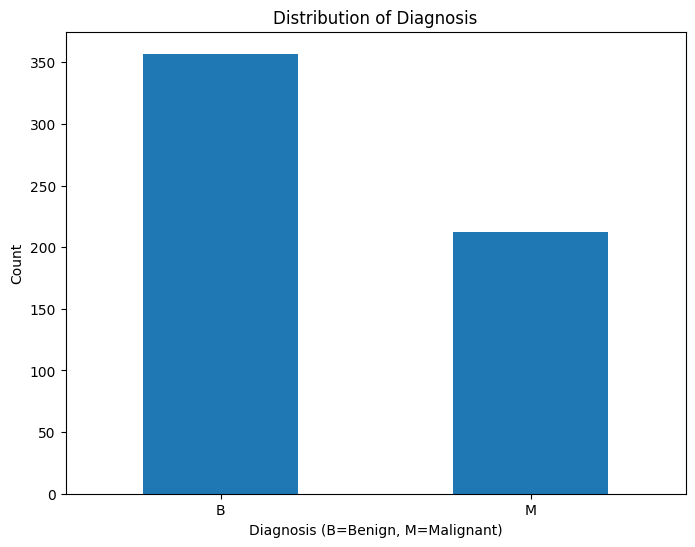


Features shape: (569, 30)
Target shape: (569,)

Training set size: 455
Test set size: 114


In [ ]:
# Check for missing values
print(f"\nMissing values per column:")
print(data.isnull().sum())

# Drop unnecessary columns (id and any unnamed columns)
if 'id' in data.columns:
    data = data.drop('id', axis=1)
if 'Unnamed: 32' in data.columns:
    data = data.drop('Unnamed: 32', axis=1)

print(f"\nDataset shape after dropping unnecessary columns: {data.shape}")

# Check target variable distribution
print(f"\nTarget variable distribution:")
print(data['diagnosis'].value_counts())

# Visualize target distribution
plt.figure(figsize=(8, 6))
data['diagnosis'].value_counts().plot(kind='bar')
plt.title('Distribution of Diagnosis')
plt.xlabel('Diagnosis (B=Benign, M=Malignant)')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()

# Convert target variable to binary (M=1, B=0)
data['diagnosis'] = data['diagnosis'].map({'M': 1, 'B': 0})

# Separate features and target
X = data.drop('diagnosis', axis=1)
y = data['diagnosis']

print(f"\nFeatures shape: {X.shape}")
print(f"Target shape: {y.shape}")

# Split the data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\nTraining set size: {X_train.shape[0]}")
print(f"Test set size: {X_test.shape[0]}")

### Step 3: Train Logistic Regression Model

In [ ]:
# TODO: Train Logistic Regression model
lr_model = LogisticRegression(random_state=42, max_iter=1000)
lr_model.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(max_iter=1000, random_state=42)

### Step 4: Evaluate Logistic Regression Model


Logistic Regression Accuracy: 0.9386

Classification Report for Logistic Regression:
              precision    recall  f1-score   support

           0       0.92      0.99      0.95        72
           1       0.97      0.86      0.91        42

    accuracy                           0.94       114
   macro avg       0.95      0.92      0.93       114
weighted avg       0.94      0.94      0.94       114


Confusion Matrix for Logistic Regression:
[[71  1]
 [ 6 36]]


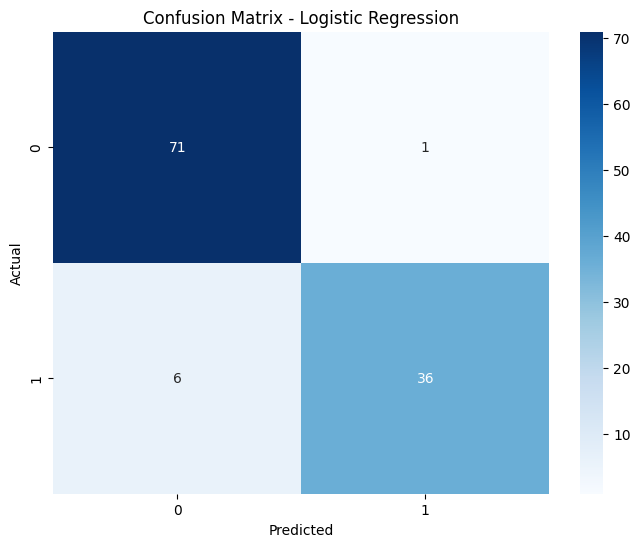

AUC Score for Logistic Regression: 0.9940


In [ ]:
# TODO: Evaluate Logistic Regression model
# Make predictions
y_pred_lr = lr_model.predict(X_test)
y_pred_proba_lr = lr_model.predict_proba(X_test)[:, 1]

# Calculate accuracy
lr_accuracy = accuracy_score(y_test, y_pred_lr)
print(f"Logistic Regression Accuracy: {lr_accuracy:.4f}")

# Classification report
print(f"\nClassification Report for Logistic Regression:")
print(classification_report(y_test, y_pred_lr))

# Confusion Matrix
print(f"\nConfusion Matrix for Logistic Regression:")
cm_lr = confusion_matrix(y_test, y_pred_lr)
print(cm_lr)

# Visualize confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - Logistic Regression')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# ROC curve and AUC
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_pred_proba_lr)
auc_lr = roc_auc_score(y_test, y_pred_proba_lr)

print(f"AUC Score for Logistic Regression: {auc_lr:.4f}")

### Step 5: Train and Compare with Another Model


Decision Tree Accuracy: 0.9298

Classification Report for Decision Tree:
              precision    recall  f1-score   support

           0       0.94      0.94      0.94        72
           1       0.90      0.90      0.90        42

    accuracy                           0.93       114
   macro avg       0.92      0.92      0.92       114
weighted avg       0.93      0.93      0.93       114

AUC Score for Decision Tree: 0.9246


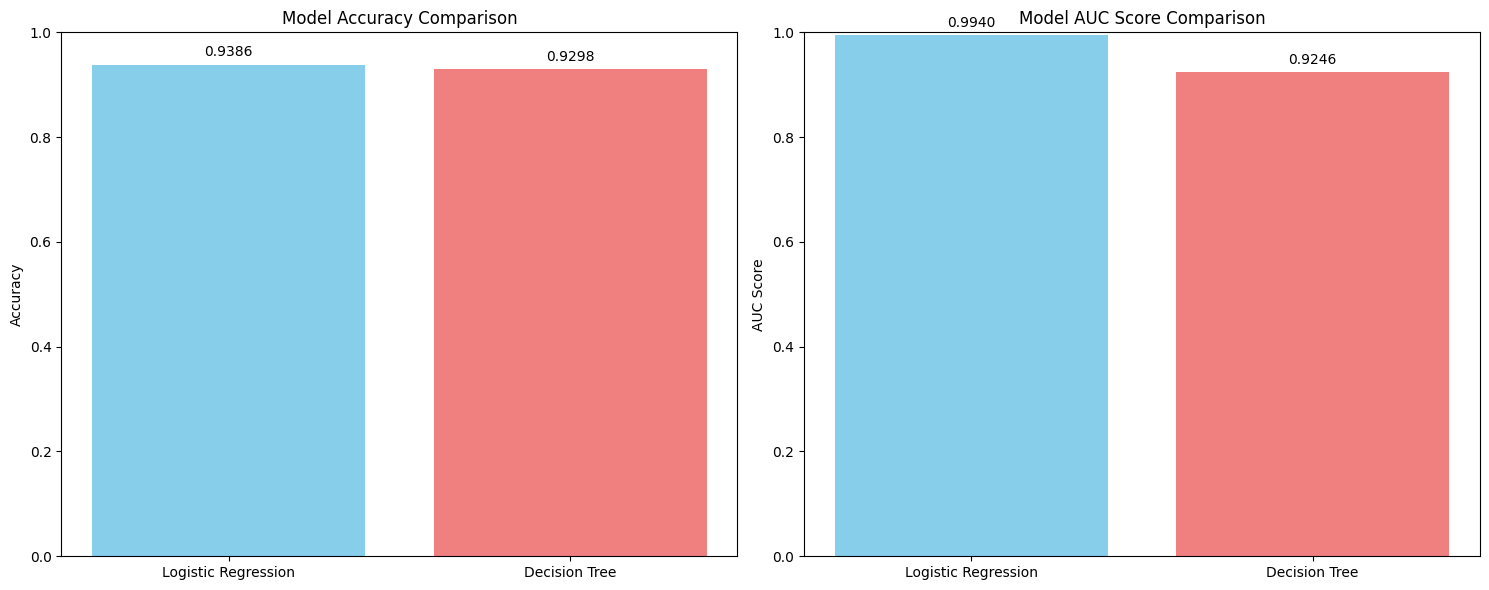

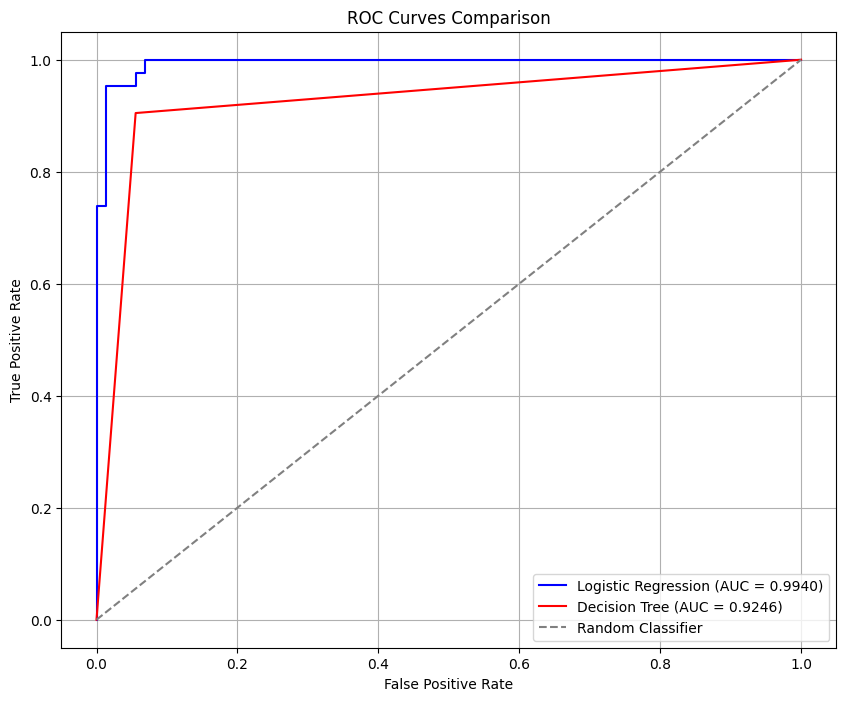


SUMMARY
Logistic Regression:
  - Accuracy: 0.9386
  - AUC Score: 0.9940

Decision Tree:
  - Accuracy: 0.9298
  - AUC Score: 0.9246

Logistic Regression performed better with 0.88% higher accuracy

Both models show excellent performance on this breast cancer dataset!


In [ ]:
# TODO: Train Decision Tree and compare accuracy with Logistic Regression
from sklearn.tree import DecisionTreeClassifier
# Train Decision Tree
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)

# Make predictions
y_pred_dt = dt_model.predict(X_test)
y_pred_proba_dt = dt_model.predict_proba(X_test)[:, 1]

# Calculate accuracy
dt_accuracy = accuracy_score(y_test, y_pred_dt)
print(f"Decision Tree Accuracy: {dt_accuracy:.4f}")

# Classification report for Decision Tree
print(f"\nClassification Report for Decision Tree:")
print(classification_report(y_test, y_pred_dt))

# AUC for Decision Tree
auc_dt = roc_auc_score(y_test, y_pred_proba_dt)
print(f"AUC Score for Decision Tree: {auc_dt:.4f}")

# Compare models with bar chart
models = ['Logistic Regression', 'Decision Tree']
accuracies = [lr_accuracy, dt_accuracy]
auc_scores = [auc_lr, auc_dt]

# Create comparison plots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Accuracy comparison
bars1 = ax1.bar(models, accuracies, color=['skyblue', 'lightcoral'])
ax1.set_title('Model Accuracy Comparison')
ax1.set_ylabel('Accuracy')
ax1.set_ylim(0, 1)
for i, bar in enumerate(bars1):
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height + 0.01,
             f'{accuracies[i]:.4f}', ha='center', va='bottom')

# AUC comparison
bars2 = ax2.bar(models, auc_scores, color=['skyblue', 'lightcoral'])
ax2.set_title('Model AUC Score Comparison')
ax2.set_ylabel('AUC Score')
ax2.set_ylim(0, 1)
for i, bar in enumerate(bars2):
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height + 0.01,
             f'{auc_scores[i]:.4f}', ha='center', va='bottom')

plt.tight_layout()
plt.show()

# ROC Curves Comparison
plt.figure(figsize=(10, 8))
fpr_dt, tpr_dt, _ = roc_curve(y_test, y_pred_proba_dt)

plt.plot(fpr_lr, tpr_lr, color='blue', label=f'Logistic Regression (AUC = {auc_lr:.4f})')
plt.plot(fpr_dt, tpr_dt, color='red', label=f'Decision Tree (AUC = {auc_dt:.4f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', label='Random Classifier')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves Comparison')
plt.legend()
plt.grid(True)
plt.show()

# Summary
print("\n" + "="*50)
print("SUMMARY")
print("="*50)
print(f"Logistic Regression:")
print(f"  - Accuracy: {lr_accuracy:.4f}")
print(f"  - AUC Score: {auc_lr:.4f}")
print(f"\nDecision Tree:")
print(f"  - Accuracy: {dt_accuracy:.4f}")
print(f"  - AUC Score: {auc_dt:.4f}")

if lr_accuracy > dt_accuracy:
    print(f"\nLogistic Regression performed better with {(lr_accuracy - dt_accuracy)*100:.2f}% higher accuracy")
else:
    print(f"\nDecision Tree performed better with {(dt_accuracy - lr_accuracy)*100:.2f}% higher accuracy")

print("\nBoth models show excellent performance on this breast cancer dataset!")